# Look at the big picture
## Task
Build a model to predict the median house price in any district in the California state.

## Bussines goals
Make the best investments buying houses in California.

### How they plan to achieve them
Through a machine learning system and experts on housing investing.

### How am I implied
Implement a model and pass its output to the machine learning system downstream.

##Current solutions
Predictions are estimated by a team of experts who gather up-to-date data about districts.

## Assumptions
- The California Housing Prices dataset looks like a good starting point
- The model predictions must be better than the expert's.
- The model output must be compatible to the machine learning system
- Experts can help to frame the problem

# Frame the problem
- **Task type**: Numerical regression
- **Training supervision**: Supervised learning
- **Training method**: batch-based learning
- **Performance measure**: low-cost function
- **Metrics to use**: RMSE
- **Minimum performance**: < 0.3

## Why
- The objective is to **predict numerical values**
- The used dataset has the target predictor on it
- The dataset is small, there is no continuos flow of data, and the system doesn't requiere to be updated rapidly with new data
- Useful to know how much error the model is making (bigger is worst)
- Ideal whem large errors are costly and keep the original scaling
- Overcome experts mean error estimation

In [ ]:
# Get the data
import requests
from pathlib import Path
import tarfile
import pandas as pd

def load_housing_df(file_name=None) -> pd.DataFrame:
  url = f"https://github.com/ageron/data/raw/main/housing.tgz"

  # create destination directory
  dest_dir= Path("datasets")
  if not dest_dir.exists():
    dest_dir.mkdir(parents=True, exist_ok=True)

  # get data from web
  response = requests.get(url)
  response.raise_for_status()

  # load compressed tar
  full_path = dest_dir.joinpath("housing.tgz")
  with open(full_path, 'wb') as compressed:
    compressed.write(response.content)

  # extract content from tgz
  with tarfile.open(full_path) as tar:
    if not file_name:
      tar.extractall(dest_dir)
    else:
      tar.extract(member=file_name, path=dest_dir)

  # return dataframe
  return pd.read_csv(dest_dir.joinpath("housing/housing.csv"))

housing = load_housing_df()

/tmp/ipython-input-463252519.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


In [ ]:
# Analyse data content
display(housing.info())
print("\nSummary statistics:")
display(housing.describe())
print("\nFirst valuesi:")
display(housing.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


Summary statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



First valuesi:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
display(housing.ocean_proximity.value_counts())
print("\nAmount of categorical values: ", housing.ocean_proximity.nunique())

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5



Amount of categorical values:  5


## Insigths
1. There are mostly non-null values
2. 9 out of 10 attributes are numerical attributes (float64)
3. The object ocean_proximity is a categorical attribute with 5 categories
4. Only total_bedrooms has missing values (207)

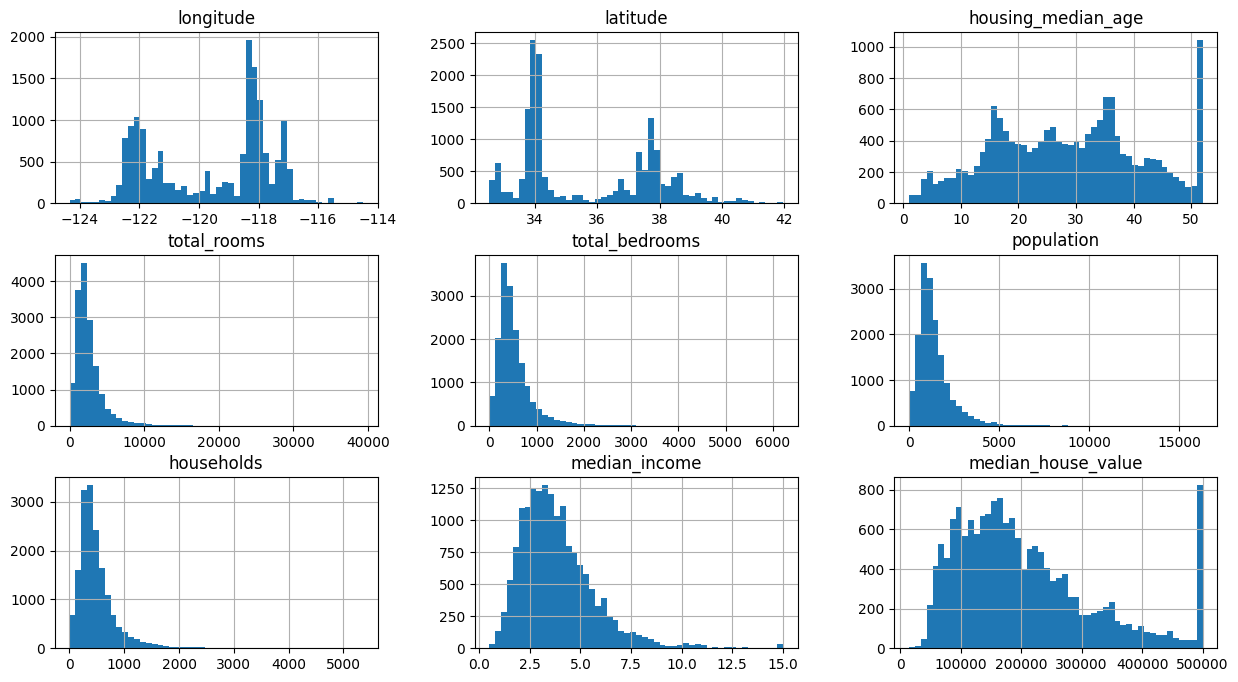

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
housing.hist(bins=50, figsize=(15,8))
plt.show()

## Insigths
1. total_rooms, total_bedrooms, population, and household are **highly rigth-skewed**
2. median_income is scaled to units instead of one hundred thousand of dollars
3. There is a **cap** of 500k in median_house_value and 50 in housing_median_age
4. Attributes has **different scales**


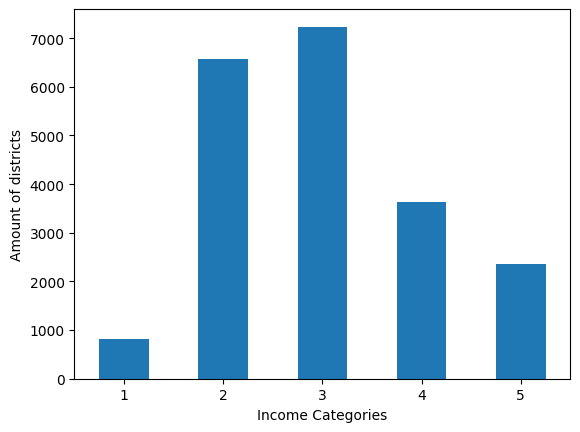

In [ ]:
# Splitting data into training and test
## Method to use: Stratified Sampling
import numpy as np
from sklearn.model_selection import train_test_split

# create categories from median_income
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0, 1.5, 3.0, 4.5, 6, np.inf],
                               labels=[1, 2, 3, 4, 5]
                              )
housing_strat = housing["income_cat"].value_counts().sort_index()

# make bar plot
housing_strat.plot.bar(xlabel="Income Categories", rot=0, ylabel="Amount of districts")
plt.show()

In [ ]:
strat_train_split, strat_test_split = train_test_split(housing, stratify=housing["income_cat"], test_size=.2, random_state=42)

In [ ]:
# random sampling vs stratified sampling comparation on full dataset
_, test_split_rand = train_test_split(housing, test_size=.2, random_state=42)
test_split_strat = strat_test_split

def get_category_percentage(df):
  return df["income_cat"].value_counts(normalize=True).sort_index() * 100

s_overall = get_category_percentage(housing)

error_percentage_measure = lambda x: ((x - s_overall) / s_overall) * 100

percent_series = [s_overall]
for df in [test_split_rand, test_split_strat]:
  result = get_category_percentage(df)
  error = error_percentage_measure(result)
  percent_series.extend((result, error))

summarize = pd.concat(percent_series, axis=1, ignore_index=True).round(2)
summarize.rename(columns={0: 'Overall%', 3: 'Stratified%', 1: 'Random%', 4: 'Strat.Error%', 2: 'Rand.Error%'}, inplace=True)
summarize = summarize.iloc[:,[0,3,1,4,2]]
summarize


,Overall%,Stratified%,Random%,Strat.Error%,Rand.Error%
income_cat,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


## Insigths
By stratifing we are making sure to not bias the samples before training the models, this way the performance will increase due to we are being the most similar to the population.

In [ ]:
# Drop stratify attribute
for set_ in (strat_train_split, strat_test_split):
  set_.drop(columns="income_cat", inplace=True)

# Copy train dataset for EDA experimentation
housing = strat_train_split.copy()

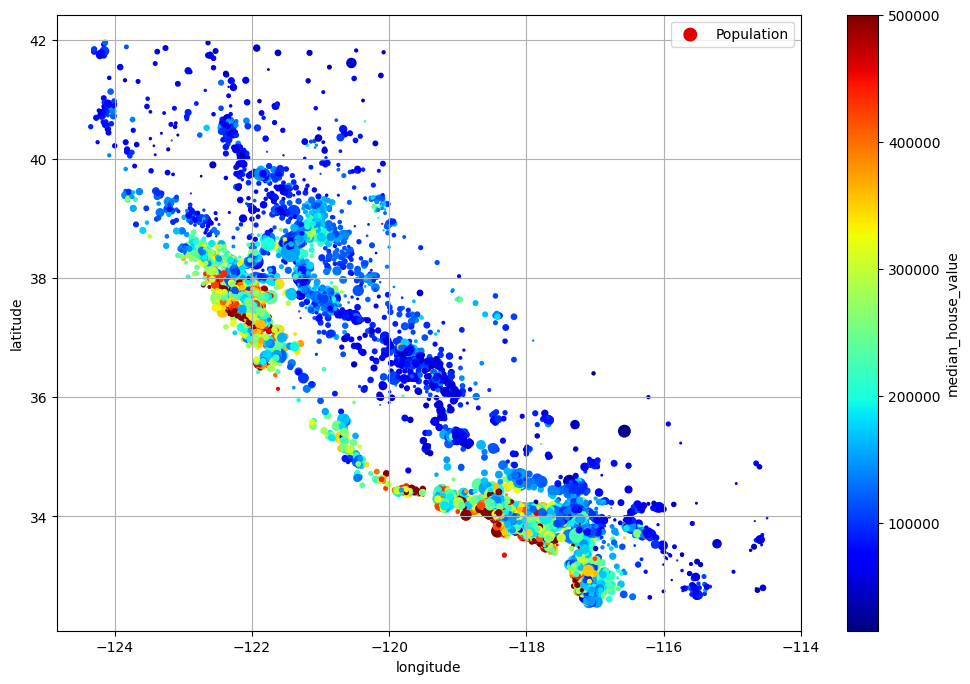

In [ ]:
# Plotting geographical data
housing.plot(kind="scatter", x="longitude", y="latitude", s=housing["population"] / 100, c='median_house_value',
             cmap='jet', label= 'Population', figsize=(12,8), grid=True, colorbar=True, legend=True,
             sharex=False)
plt.show()

## Insigths
- There is high density population near the bay both in north and south, and a bit less on north and middle center
- The expensier houses are near the bay

In [ ]:
# Computing correlations
matrix_corr = housing.corr(numeric_only=True)
matrix_corr['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


## Insigths
- The data is mostly highly rigth skewed
- There is caps in median_house_value and median_house_age

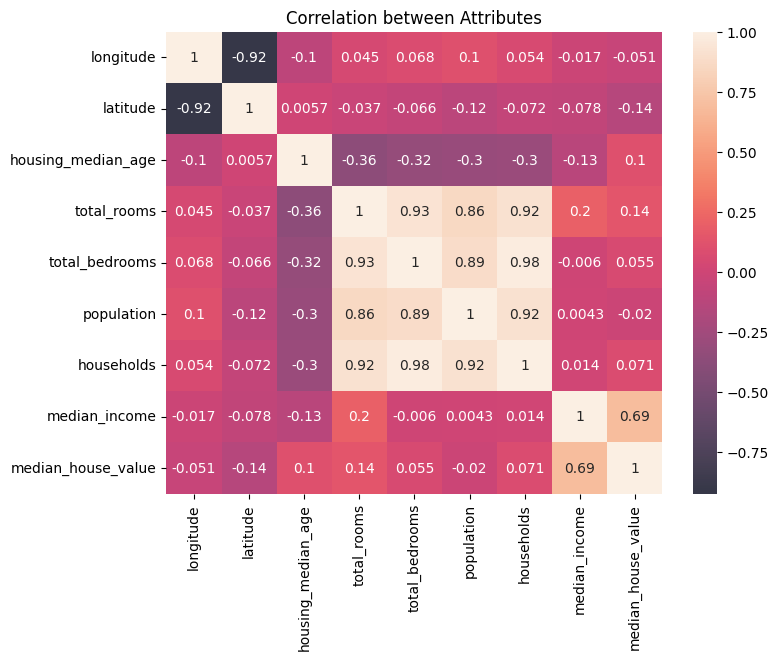

In [ ]:
# Plotting matrix correlation heatmap
fig, ax = plt.subplots()
sns.heatmap(matrix_corr, alpha=0.8, annot=True, mask=False, cbar=True, ax=ax)
ax.set(title="Correlation between Attributes")
fig.set_figwidth(8), fig.set_figheight(6)
plt.show()

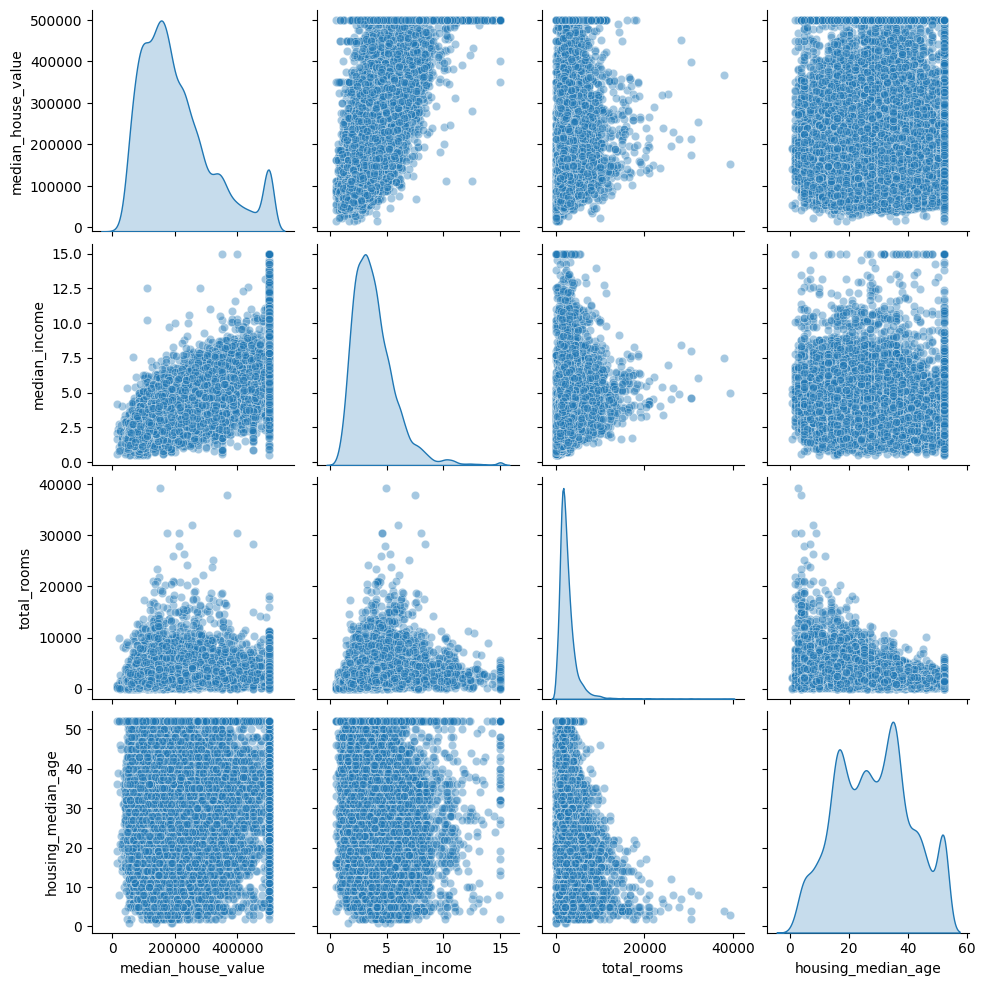

In [ ]:
# Plotting data distribution
most_related_to_label = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
sns.pairplot(housing[most_related_to_label], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()

## Insigths
- Related with median_house_value, the most correlated attribute is the median_income, then it comes after total_rooms and housing_median_age
- There is a high correlation between total_rooms, household, and total_bedrooms